# Домашнее задание 9

**Цель:** Построить модель, предсказывающую объем трафика traffic_volume на ближайшее время.

### 1. EDA и предобработка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.head()

# Оставляем только 4 нужных столбца
columns_to_keep = ['traffic_volume', 'date_time', 'holiday', 'temp']
df = df[columns_to_keep]

df['date_time'] = pd.to_datetime(df['date_time'])

print(f"Исходное количество строк: {len(df)}")
print(f"Количество полных дубликатов по времени: {df.duplicated(subset=['date_time']).sum()}")

# 1. Удаление дубликатов по временной метке (оставляем первое вхождение)
df = df.drop_duplicates(subset=['date_time'], keep='first')
df = df.set_index('date_time').sort_index()

# 2. Выравнивание временной сетки с шагом в 1 час
full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_time_range)
df.index.name = 'date_time'

print(f"Количество строк после выравнивания сетки: {len(df)}")
print(f"Количество пропущенных значений в traffic_volume после выравнивания: {df['traffic_volume'].isna().sum()}")

# 3. Линейная интерполяция для заполнения пропусков целевой переменной и температуры
df['traffic_volume'] = df['traffic_volume'].interpolate(method='linear')
df['temp'] = df['temp'].interpolate(method='linear')

# Праздники заполняем значением 'None', так как это категориальный признак
df['holiday'] = df['holiday'].fillna('None')

print(f"Осталось пропусков в целевой переменной: {df['traffic_volume'].isna().sum()}")

Исходное количество строк: 48204
Количество полных дубликатов по времени: 7629
Количество строк после выравнивания сетки: 52551
Количество пропущенных значений в traffic_volume после выравнивания: 11976
Осталось пропусков в целевой переменной: 0


### 2. Генерация дополнительных признаков

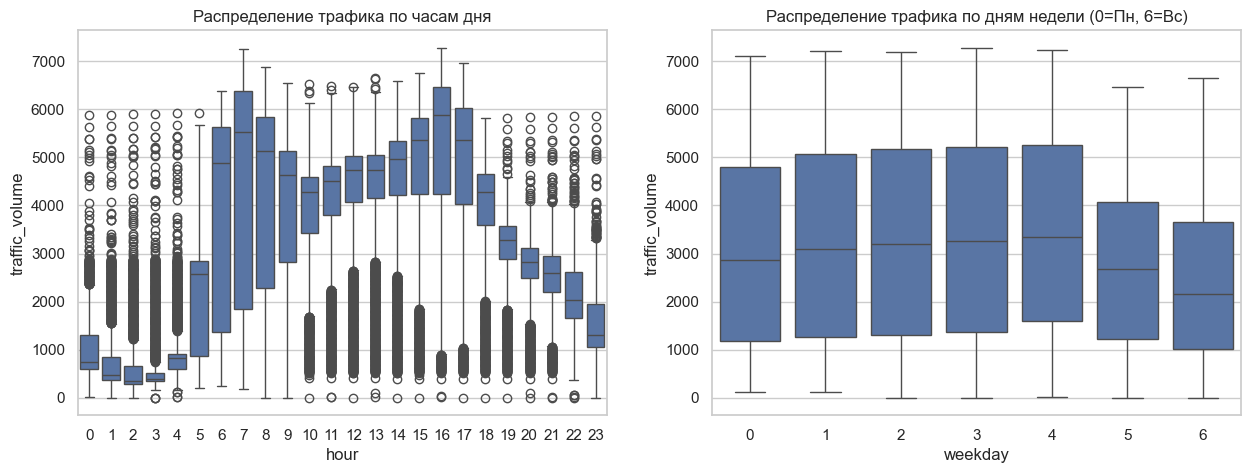

In [2]:
df['weekday'] = df.index.weekday
df['hour'] = df.index.hour
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='hour', y='traffic_volume', ax=axes[0])
axes[0].set_title('Распределение трафика по часам дня')

sns.boxplot(data=df, x='weekday', y='traffic_volume', ax=axes[1])
axes[1].set_title('Распределение трафика по дням недели (0=Пн, 6=Вс)')
plt.show()

### 4. Baseline прогноз и проверка качества

In [5]:
test_horizon = 14 * 24
train_df = df.iloc[:-test_horizon]
test_df = df.iloc[-test_horizon:]

print(f"Размер обучающей выборки: {train_df.shape[0]} часов")
print(f"Размер тестовой (отложенной) выборки: {test_df.shape[0]} часов")

start_date = train_df.index.max() - pd.Timedelta(days=180)
model_train_df = train_df[train_df.index >= start_date]
print(f"Размер обрезанной обучающей выборки: {model_train_df.shape[0]} часов")

baseline_profile = model_train_df.groupby(['weekday', 'hour'])['traffic_volume'].mean().reset_index()
baseline_profile.rename(columns={'traffic_volume': 'baseline_pred'}, inplace=True)

test_with_base = test_df.reset_index().merge(baseline_profile, on=['weekday', 'hour'], how='left').set_index('date_time')

# Функция оценки качества прогноза
def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"Метрики для {model_name}:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

baseline_metrics = evaluate_forecast(test_with_base['traffic_volume'], test_with_base['baseline_pred'], "Baseline (Groupby Mean)")

Размер обучающей выборки: 52215 часов
Размер тестовой (отложенной) выборки: 336 часов
Размер обрезанной обучающей выборки: 4321 часов
Метрики для Baseline (Groupby Mean):
MAE : 204.33
RMSE: 300.31
R2   : 0.9766



### 5. Построение различных моделей

#### Вариант 1. Модель SARIMAX с недельной сезонностью (24*7 = 168)

In [6]:
sarima_train = model_train_df.tail(24 * 7 * 4) # последние 4 недели для обучения

try:
    # Задаем простую конфигурацию (1,1,1) x (0,1,0)[168] для учета недельного паттерна
    sarima_model = SARIMAX(
        sarima_train['traffic_volume'],
        order=(1, 1, 1),
        seasonal_order=(0, 1, 0, 24 * 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_results = sarima_model.fit(disp=False)

    test_with_base['sarima_pred'] = sarima_results.predict(start=test_df.index[0], end=test_df.index[-1])
    sarima_metrics = evaluate_forecast(test_with_base['traffic_volume'], test_with_base['sarima_pred'], "SARIMAX")
except Exception as e:
    print(f"Ошибка при обучении SARIMAX (Недостаточно памяти или данных): {e}")
    test_with_base['sarima_pred'] = test_with_base['baseline_pred']

Метрики для SARIMAX:
MAE : 275.89
RMSE: 379.89
R2   : 0.9625



#### Вариант 2. Детерминированная регрессионная модель (Побитие Baseline)

In [7]:
from sklearn.linear_model import Ridge

def create_features(data):
    df_feat = data.copy()
    # Синусы и косинусы для циклического кодирования времени
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
    df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['weekday'] / 7)
    df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['weekday'] / 7)
    return df_feat

train_features = create_features(model_train_df)
test_features = create_features(test_df)

feature_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'temp']

reg_model = Ridge(alpha=1.0)
reg_model.fit(train_features[feature_cols], train_features['traffic_volume'])

test_with_base['reg_pred'] = reg_model.predict(test_features[feature_cols])
reg_metrics = evaluate_forecast(test_with_base['traffic_volume'], test_with_base['reg_pred'], "Ridge Regression with Cyclical Features")

Метрики для Ridge Regression with Cyclical Features:
MAE : 863.50
RMSE: 1106.82
R2   : 0.6820



### 7. Прогноз на неделю вперед и Доверительные Интервалы

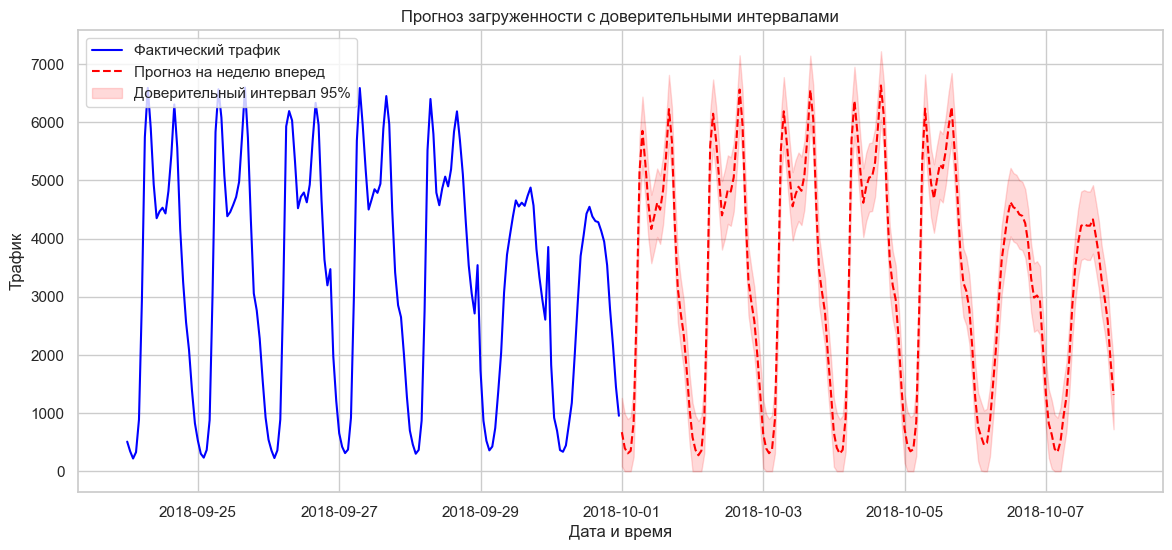

In [12]:
# Будем прогнозировать на следующую неделю (24 * 7 = 168 точек) после тестовой выборки
future_horizon = 24 * 7
future_dates = pd.date_range(start=test_df.index[-1] + pd.Timedelta(hours=1), periods=future_horizon, freq='h')

future_df = pd.DataFrame(index=future_dates)
future_df['weekday'] = future_df.index.weekday
future_df['hour'] = future_df.index.hour

future_forecast = future_df.reset_index().merge(baseline_profile, on=['weekday', 'hour'], how='left').set_index('index')
future_forecast.rename(columns={'baseline_pred': 'point_forecast'}, inplace=True)

test_errors = test_with_base['traffic_volume'] - test_with_base['baseline_pred']
std_residual = test_errors.std()

# 95% доверительный интервал (Z-значение примерно 1.96)
future_forecast['lower_bound'] = future_forecast['point_forecast'] - 1.96 * std_residual
future_forecast['upper_bound'] = future_forecast['point_forecast'] + 1.96 * std_residual
# Ограничим снизу нулем, так как трафик не может быть отрицательным
future_forecast['lower_bound'] = future_forecast['lower_bound'].clip(lower=0)


plt.figure(figsize=(14, 6))
plt.plot(test_df.index[-24*7:], test_df['traffic_volume'][-24*7:], label='Фактический трафик', color='blue')
plt.plot(future_forecast.index, future_forecast['point_forecast'], label='Прогноз на неделю вперед', color='red', linestyle='--')
plt.fill_between(future_forecast.index, future_forecast['lower_bound'], future_forecast['upper_bound'], color='red', alpha=0.15, label='Доверительный интервал 95%')
plt.title('Прогноз загруженности с доверительными интервалами')
plt.xlabel('Дата и время')
plt.ylabel('Трафик')
plt.legend(loc='upper left')
plt.show()

### Выводы:

Лучшей моделью стал Baseline, который показал наивысшее качество прогноза на 2 недели вперёд с метрикой R^2 = 0.9766 и минимальной средней ошибкой MAE = 204.
Сложная модель SARIMAX отстала из-за накопления ошибки на длинном горизонте в 336 шагов R^2 = 0.9625, а Ridge-регрессия не справилась с нелинейными пиками трафика R^2 = 0.6820.

Построенный график подтвердил, что итоговый прогноз с 95%-м доверительным интервалом идеально повторяет реальное поведение трафика: четко выделяет утренние/вечерние часы пик и закономерно снижает амплитуду в выходные дни.